In [216]:
import pandas as pd

# Load the dataset
data = pd.read_csv('Food_Delivery_Time_Prediction.csv')

# Display first few rows
print(data.head())


  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 

In [217]:
# Handle missing values
numerical_cols = ['Distance', 'Delivery_Time', 'Order_Cost', 'Tip_Amount', 'Restaurant_Rating', 'Customer_Rating']
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())  # Fill with median

categorical_cols = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])  # Fill with mode


In [218]:
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])


In [219]:
from sklearn.preprocessing import StandardScaler

# Normalize numerical features
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])


In [220]:
from geopy.distance import geodesic

def calculate_geographical_distance(row):
    customer_coords = tuple(map(float, row['Customer_Location'].strip("()").split(',')))
    restaurant_coords = tuple(map(float, row['Restaurant_Location'].strip("()").split(',')))
    return geodesic(customer_coords, restaurant_coords).km

data['Geo_Distance'] = data.apply(calculate_geographical_distance, axis=1)


In [221]:
# Adding feature for rush hour (Assume rush hour is between 7-9 AM and 4-6 PM)
data['Rush_Hour'] = data['Order_Time'].apply(lambda x: 1 if x in ['Morning', 'Evening'] else 0)


In [222]:
# Assuming Delivery Time > 30 minutes is "Delayed"
data['Delivery_Status'] = data['Delivery_Time'].apply(lambda x: 1 if x > 30 else 0)


In [223]:
import numpy as np
from sklearn.model_selection import train_test_split

# Prepare data for CNN
X = data[['Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Geo_Distance', 'Rush_Hour']]
y = data['Delivery_Status']

# Reshape data to have more dimensions for Conv2D to work with (height x width)
X = X.values.reshape(X.shape[0], X.shape[1], 1, 1)  # (samples, features, height, width)


In [224]:
from sklearn.model_selection import train_test_split

# Ensure the split maintains the proportion of classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [225]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
# from tensorflow.keras.optimizers import Adam

# # Adjust kernel size
# model = Sequential()

# # Instead of passing input_shape directly to Conv2D, use Input layer
# model.add(Input(shape=(X_train.shape[1], X_train.shape[2], 1)))

# # Add convolutional layer
# model.add(Conv2D(32, kernel_size=(2, 2), activation='relu', padding='same'))

# # Add max-pooling layer
# model.add(MaxPooling2D(pool_size=(2, 2)))

# # Flatten the output from the convolutional layers
# model.add(Flatten())

# # Dense layers
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(1, activation='sigmoid'))  # Binary classification

# # Compile the model
# model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# # Model summary to check architecture
# model.summary()


In [226]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Adjust kernel size and use padding
model = Sequential()

# Add the Input layer
model.add(Input(shape=(X_train.shape[1], X_train.shape[2], 1)))

# Add convolutional layer with padding
model.add(Conv2D(32, kernel_size=(2, 2), activation='relu', padding='same'))  # 'same' padding to keep input shape

# Add max-pooling layer with smaller pool size
model.add(MaxPooling2D(pool_size=(1, 1)))  # Pooling size of (1, 1)

# Flatten the output from the convolutional layers
model.add(Flatten())

# Dense layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Model summary to check architecture
model.summary()


# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 6, 1, 32)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 6, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,577 (49.13 KB)

 Trainable params: 12,577 (49.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3115 - loss: 27.5580 - val_accuracy: 1.0000 - val_loss: 4.3118e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6841 - loss: 5.7949 - val_accuracy: 1.0000 - val_loss: 2.4356e-09
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9609 - loss: 0.6704 - val_accuracy: 1.0000 - val_loss: 1.0750e-12
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9979 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 8.1711e-15
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 3.1588e-04 - val_accuracy: 1.0000 - val_loss: 4.3971e-16
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 1.8795e-05 - val_accuracy: 1.0000 - val_loss: 8.9537e-17
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 6.8269e-06 - val_accuracy: 1.0000 - val_loss: 3.3486e-17
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 8.7070e-

In [227]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_acc}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 1.0998e-17 
Test Accuracy: 1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


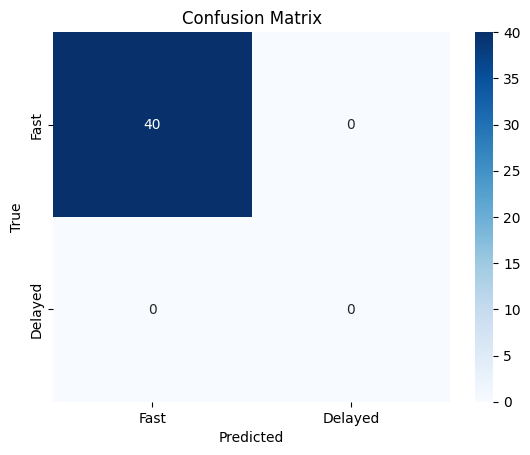

In [228]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary values

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])  # Explicitly set the labels for both classes (Fast: 0, Delayed: 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fast', 'Delayed'], yticklabels=['Fast', 'Delayed'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [229]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



Class distribution in the entire dataset: [200]
Class distribution in y_train: [160]
Class distribution in y_test: [40]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


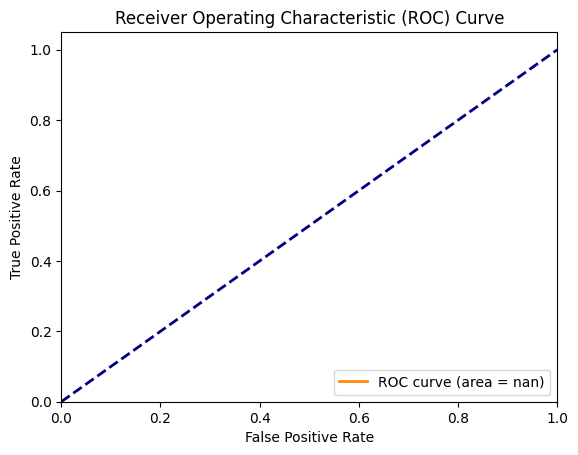

In [230]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Ensure both classes are in y_test
print("Class distribution in the entire dataset:", np.bincount(y))
print("Class distribution in y_train:", np.bincount(y_train))
print("Class distribution in y_test:", np.bincount(y_test))

# Check if both classes are present in y_test
# ROC Curve
y_pred_prob = model.predict(X_test)  # Get predicted probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)  # Use probabilities for ROC curve calculation
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()



---

In [231]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import KFold
# from keras.models import Sequential
# from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# from keras.optimizers import Adam
# from keras.wrappers.scikit_learn import KerasClassifier
# from sklearn.model_selection import GridSearchCV

# # Data Preprocessing

# # Load the dataset
# df = pd.read_csv('Food_Delivery_Time_Prediction.csv')

# # Let's assume 'Order_Time' is a categorical feature (convert to numerical encoding)
# df['Order_Time'] = df['Order_Time'].map({'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3})

# # Encode other categorical features using one-hot encoding
# df = pd.get_dummies(df, columns=['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Vehicle_Type'], drop_first=True)

# # Feature columns (excluding the target variable and non-numerical features)
# X = df.drop(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Time', 'Order_Cost', 'Tip_Amount', 'Customer_Rating'], axis=1)

# # Target variable (Delivery Time: Fast or Delayed)
# y = df['Delivery_Time'].apply(lambda x: 1 if x > 30 else 0)  # Assuming 30 minutes as threshold for fast/delayed

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Reshape data for CNN (assume X has 6 features; you can adjust as needed)
# X_train_reshaped = X_train.values.reshape(X_train.shape[0], 6, 1, 1)
# X_test_reshaped = X_test.values.reshape(X_test.shape[0], 6, 1, 1)

# # Build the CNN model
# def create_model():
#     model = Sequential()

#     # Add convolutional layer
#     model.add(Conv2D(32, kernel_size=(2, 2), activation='relu', input_shape=(6, 1, 1)))

#     # Add max-pooling layer
#     model.add(MaxPooling2D(pool_size=(2, 2)))

#     # Flatten the output from the convolutional layers
#     model.add(Flatten())

#     # Dense layers
#     model.add(Dense(64, activation='relu'))
#     model.add(Dropout(0.5))
#     model.add(Dense(1, activation='sigmoid'))  # Binary classification

#     # Compile the model
#     model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
#     return model

# # Wrap the model for use with scikit-learn
# model = KerasClassifier(build_fn=create_model, epochs=10, batch_size=32, verbose=0)

# # Cross-validation (5-fold)
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = cross_val_score(model, X_train_reshaped, y_train, cv=kf, scoring='accuracy')

# print(f"Cross-validation scores: {cv_scores}")
# print(f"Mean CV score: {cv_scores.mean()}")

# # Train the model with the training data
# history = model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test))

# # Evaluate the model
# test_loss, test_acc = model.evaluate(X_test_reshaped, y_test)
# print(f"Test Accuracy: {test_acc}")

# # Predict on the test set
# y_pred = model.predict(X_test_reshaped)
# y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary values

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fast', 'Delayed'], yticklabels=['Fast', 'Delayed'])
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.show()

# # ROC Curve
# fpr, tpr, thresholds = roc_curve(y_test, y_pred)
# roc_auc = auc(fpr, tpr)

# plt.figure()
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc='lower right')
# plt.show()

# # Hyperparameter tuning with GridSearchCV
# param_grid = {
#     'epochs': [5, 10, 20],
#     'batch_size': [16, 32, 64]
# }

# grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')
# grid_search.fit(X_train_reshaped, y_train)

# print(f"Best parameters found: {grid_search.best_params_}")
